In [1]:
from google.colab import drive
import pandas as pd
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the directory path
dir_path = "/content/drive/MyDrive/sp500_csv"

# Get the list of files in the directory
file_list = os.listdir(dir_path)

# Assuming you want to read the first CSV file in the directory:
file_path = os.path.join(dir_path, file_list[0])

# Load CSV into DataFrame
df = pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,04-04-1995,2.81250,2.93750,40387200,2.96875,2.953125,2.275675
1,05-04-1995,2.84375,2.90625,12236800,2.96875,2.843750,2.191389
2,06-04-1995,2.84375,2.84375,3776000,2.93750,2.890625,2.227511
3,07-04-1995,2.84375,2.90625,1920800,2.90625,2.843750,2.191389
4,10-04-1995,2.84375,2.84375,2047200,2.90625,2.875000,2.215471


In [2]:
import os

# Define path
drive_path = "/content/drive/MyDrive/sp500_csv"

# List files
print(os.listdir(drive_path))

['ABC.csv', 'A.csv', 'AAPL.csv', 'AAP.csv', 'AAL.csv', 'ABBV.csv', 'ABMD.csv', 'AEE.csv', 'ACN.csv', 'ADSK.csv', 'ADM.csv', 'ADI.csv', 'ABT.csv', 'ADP.csv', 'AJG.csv', 'ALGN.csv', 'AEP.csv', 'ALB.csv', 'ALK.csv', 'AIZ.csv', 'AKAM.csv', 'AMAT.csv', 'AMD.csv', 'AMT.csv', 'ALTR.csv', 'AMGN.csv', 'ALLE.csv', 'AMP.csv', 'AME.csv', 'AOS.csv', 'APA.csv', 'AON.csv', 'AMZN.csv', 'ANET.csv', 'AWK.csv', 'ARE.csv', 'AVB.csv', 'AVY.csv', 'APH.csv', 'ATVI.csv', 'APD.csv', 'AXP.csv', 'BA.csv', 'BAX.csv', 'BBY.csv', 'BAC.csv', 'AZO.csv', 'BDX.csv', 'BLK.csv', 'BF-A.csv', 'BIO.csv', 'BIIB.csv', 'BMRA.csv', 'BK.csv', 'BHI.csv', 'BEN.csv', 'BSX.csv', 'BWA.csv', 'BXP.csv', 'BMY.csv', 'BSHI.csv', 'BR.csv', 'BRK-A.csv', 'CDNS.csv', 'CAT.csv', 'CAH.csv', 'CB.csv', 'CDE.csv', 'CCI.csv', 'C.csv', 'CAG.csv', 'CF.csv', 'CL.csv', 'CHTR.csv', 'CHRW.csv', 'CFG.csv', 'CHD.csv', 'CINF.csv', 'CMI.csv', 'CMG.csv', 'CME.csv', 'CNWT.csv', 'CLX.csv', 'CNC.csv', 'CNP.csv', 'COWN.csv', 'CPRT.csv', 'COO.csv', 'COP.csv', 'CPB

In [3]:
pip install numpy pandas matplotlib


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the directory path
dir_path = "/content/drive/MyDrive/sp500_csv"

# Get the list of files in the directory
file_list = os.listdir(dir_path)

# Create an empty list to store the dataframes
dfs = []

# Iterate over the files and read them into dataframes
for file_name in file_list:
    file_path = os.path.join(dir_path, file_name)
    df = pd.read_csv(file_path)
    # Add a 'Stock' column with the file name (assuming it represents the stock symbol)
    df['Stock'] = file_name[:-4]  # Remove '.csv' from file name
    dfs.append(df)

# Concatenate all dataframes into a single dataframe
combined_data = pd.concat(dfs, ignore_index=True)


# Check the structure of the combined data
print("Data Info:")
print(combined_data.info())

# Check for missing values
print("\nMissing Values:")
print(combined_data.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(combined_data.describe())

# Check unique stocks in the dataset
print("\nUnique Stocks:")
print(combined_data['Stock'].nunique())  # Use nunique() to get the count of unique stocks
print(combined_data['Stock'].unique())  # Use unique() to list all unique stock names



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3273073 entries, 0 to 3273072
Data columns (total 18 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Date               object 
 1   Low                float64
 2   Open               float64
 3   Volume             float64
 4   High               float64
 5   Close              float64
 6   Adjusted Close     float64
 7   Stock              object 
 8   Metric             object 
 9   Value              float64
 10  Daily_Return       float64
 11  Cumulative_Return  float64
 12  Transaction_Type   object 
 13  Volatility         float64
 14  Max_Drawdown       float64
 15  Average_Volume     float64
 16  Sharpe_Ratio       float64
 17  Ticker             object 
dtypes: float64(13), object(5)
memory usage: 449.5+ MB
None

Missing Values:
Date                       6
L

In [6]:
import pandas as pd
import numpy as np

# Sample data (replace this with your actual data loading step)
# combined_data = pd.read_csv('your_stock_data.csv')

# Step 1: Convert 'Date' column to datetime format
combined_data['Date'] = pd.to_datetime(combined_data['Date'], format='%d-%m-%Y', errors='coerce')

# Step 2: Handle missing values
# Fill missing values with forward fill (ffill) or backward fill (bfill)
combined_data.fillna(method='ffill', inplace=True)  # Forward fill
combined_data.fillna(method='bfill', inplace=True)  # Backward fill (if any remaining NaNs)

# Step 3: Sort data by 'Stock' and 'Date'
combined_data.sort_values(by=['Stock', 'Date'], inplace=True)

# Step 4: Calculate daily returns for each stock
# Daily Return = (Price_t - Price_t-1) / Price_t-1
combined_data['Daily_Return'] = combined_data.groupby('Stock')['Close'].pct_change()

# Drop rows with NaN values in 'Daily_Return' (first row for each stock will be NaN)
combined_data.dropna(subset=['Daily_Return'], inplace=True)

# Step 5: Reset index (optional, but recommended for cleaner data)
combined_data.reset_index(drop=True, inplace=True)

# Display the preprocessed data
print(combined_data.head())


<ipython-input-6-45820c252018>:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_data.fillna(method='ffill', inplace=True)  # Forward fill
<ipython-input-6-45820c252018>:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_data.fillna(method='bfill', inplace=True)  # Backward fill (if any remaining NaNs)


        Date        Low       Open      Volume       High      Close  \
0 1999-11-19  28.478184  30.713518  15234146.0  30.758226  28.880545   
1 1999-11-22  28.657009  29.551144   6577870.0  31.473534  31.473534   
2 1999-11-23  28.612303  30.400572   5975611.0  31.205294  28.612303   
3 1999-11-24  28.612303  28.701717   4843231.0  29.998213  29.372318   
4 1999-11-26  29.148785  29.238197   1729466.0  29.685265  29.461731   

   Adjusted Close Stock                 Metric     Value  Daily_Return  \
0       24.711119     A  Annualized Volatility  0.326581     -0.082386   
1       26.929760     A  Annualized Volatility  0.326581      0.089783   
2       24.481602     A  Annualized Volatility  0.326581     -0.090909   
3       25.131901     A  Annualized Volatility  0.326581      0.026563   
4       25.208408     A  Annualized Volatility  0.326581      0.003044   

   Cumulative_Return Transaction_Type  Volatility  Max_Drawdown  \
0           0.888889              Buy    0.449099     -

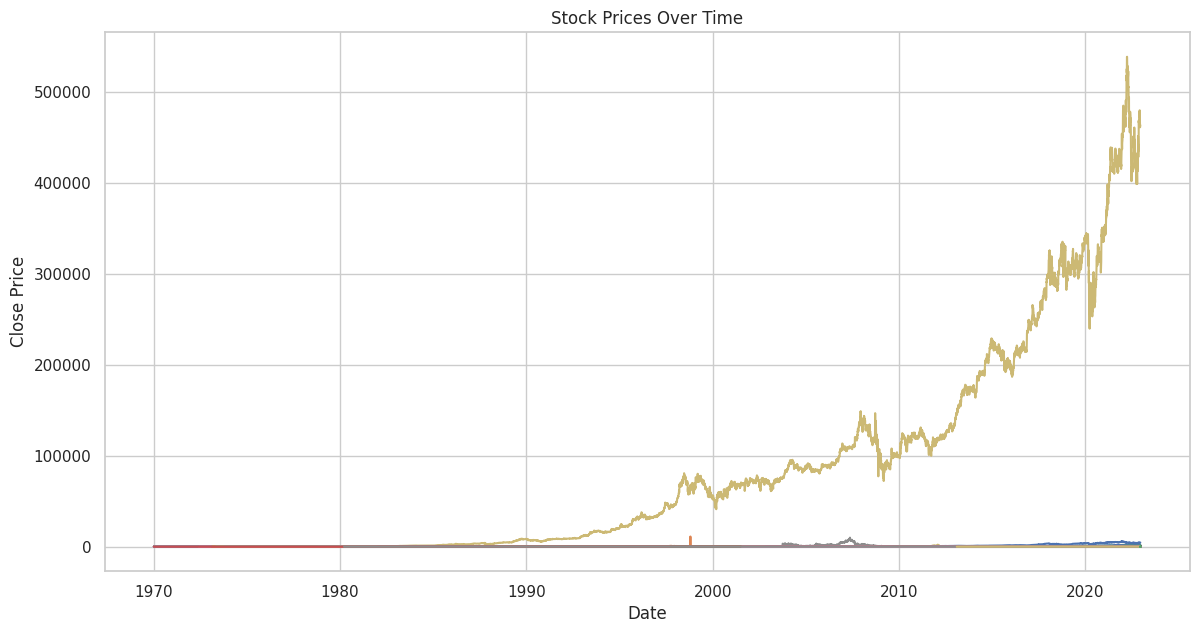

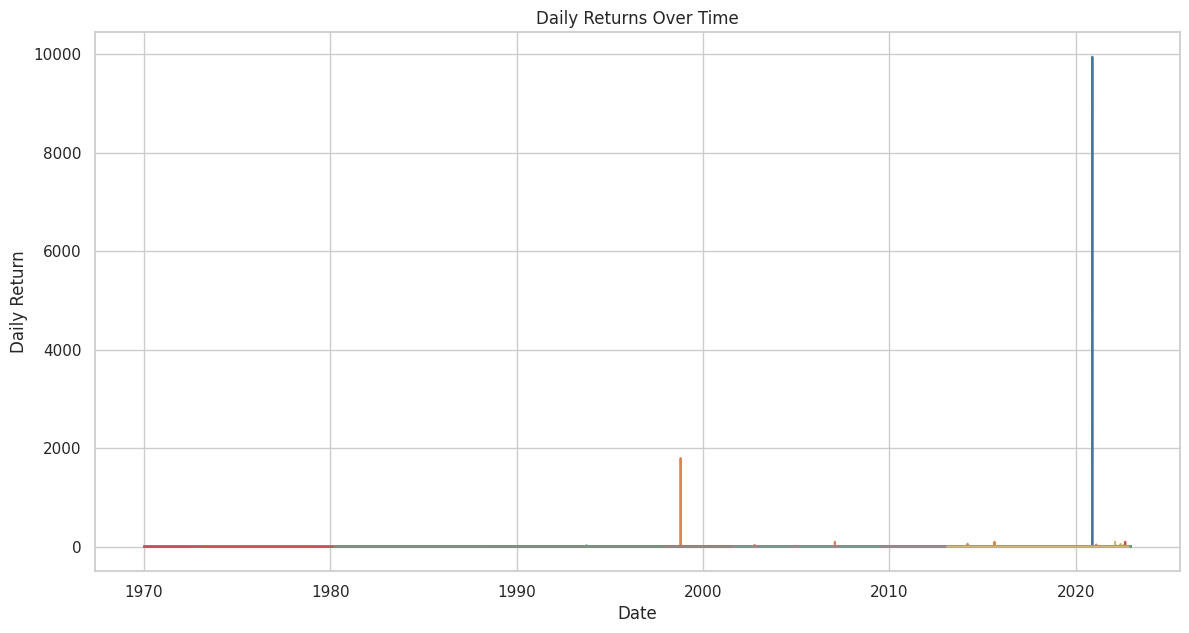

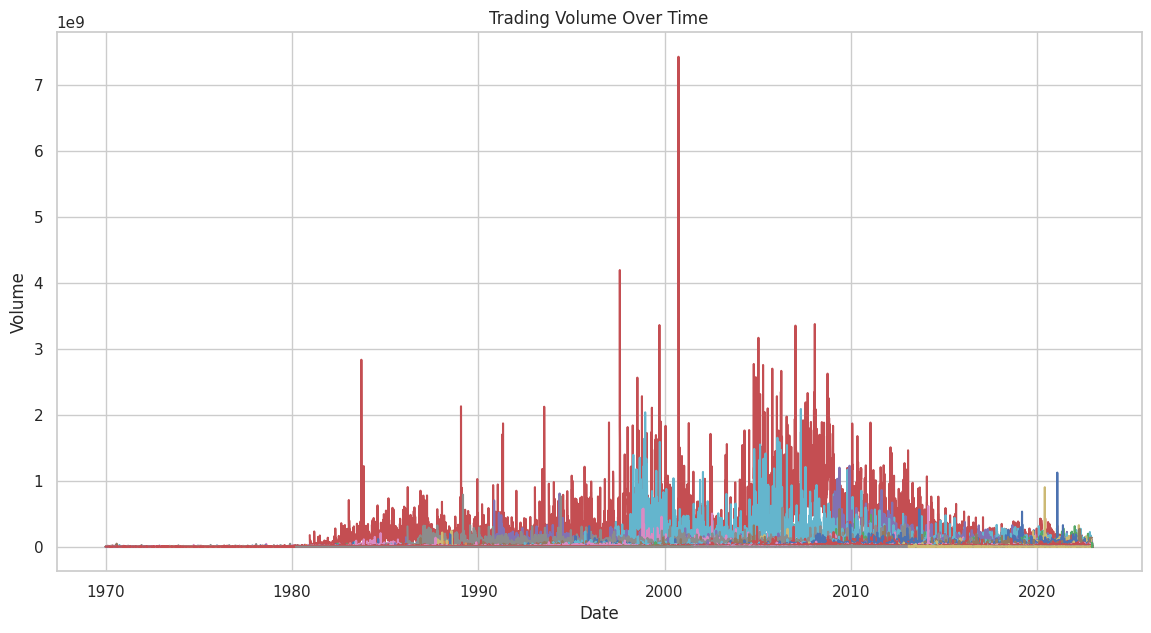

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better visualization
sns.set(style="whitegrid")

# Plot 1: Stock Prices Over Time
plt.figure(figsize=(14, 7))
for stock in combined_data['Stock'].unique():
    stock_data = combined_data[combined_data['Stock'] == stock]
    plt.plot(stock_data['Date'], stock_data['Close'], label=stock)

plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
#plt.legend(title='Stock')
plt.show()

# Plot 2: Daily Returns Over Time
plt.figure(figsize=(14, 7))
for stock in combined_data['Stock'].unique():
    stock_data = combined_data[combined_data['Stock'] == stock]
    plt.plot(stock_data['Date'], stock_data['Daily_Return'], label=stock)

plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
#plt.legend(title='Stock')
plt.show()

# Plot 3: Volume Over Time
plt.figure(figsize=(14, 7))
for stock in combined_data['Stock'].unique():
    stock_data = combined_data[combined_data['Stock'] == stock]
    plt.plot(stock_data['Date'], stock_data['Volume'], label=stock)

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
#plt.legend(title='Stock')
plt.show()

In [8]:
# Function to calculate Absolute Return and ROI
def calculate_absolute_return_roi(df):

    if 'Close' not in df.columns:
        raise ValueError("Ensure the dataset has a 'Close' column.")

    # Get the initial and final closing prices
    initial_price = df['Close'].iloc[0]
    final_price = df['Close'].iloc[-1]

    # Calculate Absolute Return
    absolute_return = final_price - initial_price

    # Calculate ROI
    roi = ((final_price - initial_price) / initial_price) * 100

    return {
        'Absolute Return': absolute_return,
        'ROI (%)': roi
    }

import os
import pandas as pd

# Define path (Make sure this is the correct path to your stock data)
dir_path = "/content/drive/MyDrive/sp500_csv"

# Define the stocks to analyze (replace with your desired stock tickers)
stocks_to_analyze = ['AAPL.csv', 'MSFT.csv', 'GOOG.csv']  # Example list of stock files

# Analyze each stock and store results
results = []
for stock_file in stocks_to_analyze:
    # Load the stock data from the CSV file
    stock_path = os.path.join(dir_path, stock_file) # Corrected path using os.path.join

    # Check if file exists
    if not os.path.isfile(stock_path):
        print(f"Warning: File {stock_path} does not exist or is not a file. Skipping...")
        continue

    stock_data = pd.read_csv(stock_path) # Read the CSV file using the corrected path

    # Ensure the DataFrame has the required columns
    required_columns = ['Date', 'Close']
    if not all(column in stock_data.columns for column in required_columns):
        raise ValueError(f"CSV file {stock_file} must contain 'Date' and 'Close' columns.")

    # Convert 'Date' column to datetime format
    stock_data['Date'] = pd.to_datetime(stock_data['Date'], format='%d-%m-%Y', errors='coerce')

    # Sort by date (if not already sorted)
    stock_data = stock_data.sort_values(by='Date')

    # Extract the stock ticker from the file name
    ticker = stock_file.split('.')[0]

    # Calculate Absolute Return and ROI
    metrics = calculate_absolute_return_roi(stock_data)
    metrics['Ticker'] = ticker

    # Append results
    results.append(metrics)

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display the results
print("Absolute Return and ROI for Each Stock:")
print(results_df)

Absolute Return and ROI for Each Stock:
   Absolute Return        ROI (%) Ticker
0       142.111658  110723.708484   AAPL
1       250.652778  257814.874278   MSFT
2        89.975865    3600.283034   GOOG


In [16]:
import pandas as pd

def calculate_technical_indicators(df, sma_period=10, rsi_period=14):
    # Ensure 'Close' column exists
    if 'Close' not in df.columns:
        raise ValueError("Dataset must have a 'Close' column.")

    # Calculate Simple Moving Average (SMA)
    df[f'SMA_{sma_period}'] = df['Close'].rolling(window=sma_period, min_periods=1).mean()

    # Calculate Relative Strength Index (RSI)
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=rsi_period, min_periods=1).mean()
    avg_loss = loss.rolling(window=rsi_period, min_periods=1).mean()

    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    return df

# Use the combined_data DataFrame instead of df
# Convert 'Date' to datetime format
combined_data['Date'] = pd.to_datetime(combined_data['Date'])

# Calculate indicators using combined_data
combined_data = calculate_technical_indicators(combined_data, sma_period=10, rsi_period=14)

# Debugging: Check for NaN values
print(combined_data[['Date', 'Close', f'SMA_10', 'RSI']].dropna().head())  # Ensure output is displayed

        Date      Close     SMA_10         RSI
1 1999-11-22  31.473534  30.177039  100.000000
2 1999-11-23  28.612303  29.655460   47.540969
3 1999-11-24  29.372318  29.584675   53.956831
4 1999-11-26  29.461731  29.560086   54.609920
5 1999-11-29  30.132332  29.655460   58.974351


In [17]:
from sklearn.preprocessing import MinMaxScaler

# Select the features to normalize (e.g., 'Close', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'RSI')
features_to_normalize = ['Close', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'RSI']

# Initialize the MinMaxScaler (normalizes data to a range of 0 to 1)
scaler = MinMaxScaler()

# Normalize the selected features
combined_data[features_to_normalize] = scaler.fit_transform(combined_data[features_to_normalize])

# Display the normalized data
print(combined_data.head())

        Date        Low       Open    Volume       High     Close  \
0 1999-11-19  28.478184  30.713518  0.002053  30.758226  0.000054   
1 1999-11-22  28.657009  29.551144  0.000886  31.473534  0.000058   
2 1999-11-23  28.612303  30.400572  0.000805  31.205294  0.000053   
3 1999-11-24  28.612303  28.701717  0.000653  29.998213  0.000054   
4 1999-11-26  29.148785  29.238197  0.000233  29.685265  0.000055   

   Adjusted Close Stock                 Metric     Value  ...  \
0       24.711119     A  Annualized Volatility  0.326581  ...   
1       26.929760     A  Annualized Volatility  0.326581  ...   
2       24.481602     A  Annualized Volatility  0.326581  ...   
3       25.131901     A  Annualized Volatility  0.326581  ...   
4       25.208408     A  Annualized Volatility  0.326581  ...   

   Transaction_Type  Volatility Max_Drawdown  Average_Volume  Sharpe_Ratio  \
0               Buy    0.449099    -0.822166    3.279583e+08       0.55549   
1               Buy    0.449099    -0.

In [22]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Sample data (replace this with your actual data loading step)
# combined_data = pd.read_csv('your_stock_data.csv')

# Ensure 'Date' is in datetime format and sort by 'Stock' and 'Date'
combined_data['Date'] = pd.to_datetime(combined_data['Date'])
combined_data.sort_values(by=['Stock', 'Date'], inplace=True)

# Calculate daily returns if not already calculated
combined_data['Daily_Return'] = combined_data.groupby('Stock')['Close'].pct_change()
combined_data.dropna(subset=['Daily_Return'], inplace=True)

# Function to calculate VaR (Value at Risk)
def calculate_var(returns, confidence_level=0.95):
    """
    Calculate VaR using the historical method.
    :param returns: Array of daily returns.
    :param confidence_level: Confidence level for VaR (e.g., 0.95 for 95%).
    :return: VaR value.
    """
    return np.percentile(returns, 100 * (1 - confidence_level))

# Function to calculate CVaR (Conditional Value at Risk)
def calculate_cvar(returns, confidence_level=0.95):
    """
    Calculate CVaR using the historical method.
    :param returns: Array of daily returns.
    :param confidence_level: Confidence level for CVaR (e.g., 0.95 for 95%).
    :return: CVaR value.
    """
    var = calculate_var(returns, confidence_level)
    return returns[returns <= var].mean()

# Calculate VaR and CVaR for each stock
results = []
for stock in combined_data['Stock'].unique():
    stock_data = combined_data[combined_data['Stock'] == stock]
    returns = stock_data['Daily_Return']

    var = calculate_var(returns, confidence_level=0.95)
    cvar = calculate_cvar(returns, confidence_level=0.95)

    results.append({
        'Stock': stock,
        'VaR_95': var,
        'CVaR_95': cvar
    })

# Convert results to a DataFrame
risk_metrics = pd.DataFrame(results)

# Display the results
print(risk_metrics)

    Stock    VaR_95   CVaR_95
0       A -0.038117 -0.060197
1     AAL -0.058750 -0.094494
2     AAP -0.028223 -0.045892
3    AAPL -0.041097 -0.061735
4    ABBV -0.024956 -0.040437
..    ...       ...       ...
347  SWKS -0.056339 -0.084107
348   SYF -0.033034 -0.057706
349   SYK -0.030479 -0.046695
350     T -0.024453 -0.036646
351   TAP -0.029801 -0.046910

[352 rows x 3 columns]


In [23]:
import gym
import numpy as np
import pandas as pd
from gym import spaces

class StockTradingEnv(gym.Env):
    """
    Custom Trading Environment for Reinforcement Learning

    State Space:
        - Open Price
        - High Price
        - Low Price
        - Close Price
        - Volume
        - Portfolio Holdings (Cash & Shares)

    Action Space:
        - Continuous action: Buy, Sell, or Hold

    Reward:
        - Profit/Loss after each step
    """

    def __init__(self, df, initial_balance=10000, max_steps=500):
        super(StockTradingEnv, self).__init__()

        # Load stock data
        self.df = df
        self.initial_balance = initial_balance
        self.current_step = 0
        self.max_steps = min(len(df) - 1, max_steps)  # Limit episode length

        # Define action space (continuous - buy/sell percentage)
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # Define observation space (5 stock features + portfolio balance)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32
        )

        # Reset environment
        self.reset()

    def reset(self):
        """ Reset environment for a new episode """
        self.current_step = 0
        self.balance = self.initial_balance
        self.shares_held = 0
        self.total_value = self.initial_balance

        return self._next_observation()

    def _next_observation(self):
        """ Get next state (observation) """
        state = self.df.iloc[self.current_step][['Open', 'High', 'Low', 'Close', 'Volume']].values
        portfolio_info = np.array([self.balance + self.shares_held * self.df.iloc[self.current_step]['Close']])
        return np.concatenate((state, portfolio_info))

    def step(self, action):
        """ Execute a trading step """

        # Get stock price data
        current_price = self.df.iloc[self.current_step]['Close']

        # Action: -1 (sell all), 0 (hold), 1 (buy max)
        action = np.clip(action, -1, 1)[0]

        # Calculate trade size
        trade_amount = action * self.balance  # Percentage of balance
        shares_traded = trade_amount // current_price  # Number of shares

        # Execute trade
        if action > 0:  # Buy
            self.shares_held += shares_traded
            self.balance -= shares_traded * current_price

        elif action < 0:  # Sell
            self.balance += self.shares_held * current_price
            self.shares_held = 0  # Sell all

        # Calculate new total value
        self.total_value = self.balance + (self.shares_held * current_price)

        # Reward = Change in portfolio value
        reward = self.total_value - self.initial_balance

        # Move to next step
        self.current_step += 1
        done = self.current_step >= self.max_steps or self.balance < 0

        return self._next_observation(), reward, done, {}

    def render(self):
        """ Render the environment (optional for visualization) """
        print(f"Step: {self.current_step}, Balance: {self.balance:.2f}, Shares Held: {self.shares_held}, Total Value: {self.total_value:.2f}")



In [25]:
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 757.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

In [29]:
!pip install shimmy>=2.0

In [47]:
import gym
import numpy as np
import pandas as pd
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.evaluation import evaluate_policy
from gym import spaces


class StockTradingEnv(gym.Env):

    def __init__(self, df, initial_balance=10000, max_steps=500):
        super(StockTradingEnv, self).__init__()

        self.df = df
        self.initial_balance = initial_balance
        self.current_step = 0
        self.max_steps = min(len(df) - 1, max_steps)

        # Action space: Continuous Buy/Sell (-1 to 1)
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)

        # Observation space: 5 stock features + portfolio balance
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32
        )

        self.reset()

    def reset(self):
        """Reset the environment"""
        self.current_step = 0
        self.balance = self.initial_balance
        self.shares_held = 0
        self.total_value = self.initial_balance
        return self._next_observation()

    def _next_observation(self):
        """Return the current state"""
        state = self.df.iloc[self.current_step][['Open', 'High', 'Low', 'Close', 'Volume']].values
        portfolio_info = np.array([self.balance + self.shares_held * self.df.iloc[self.current_step]['Close']])
        return np.concatenate((state, portfolio_info))

    def step(self, action):
        """Execute a trade and update the state"""
        current_price = self.df.iloc[self.current_step]['Close']
        action = np.clip(action, -1, 1)[0]

        # Trade size based on balance
        trade_amount = action * self.balance
        shares_traded = trade_amount // current_price

        if action > 0:  # Buy
            self.shares_held += shares_traded
            self.balance -= shares_traded * current_price

        elif action < 0:  # Sell
            self.balance += self.shares_held * current_price
            self.shares_held = 0

        # Update portfolio value
        self.total_value = self.balance + (self.shares_held * current_price)
        reward = self.total_value - self.initial_balance  # Profit/Loss as reward

        # Move to next step
        self.current_step += 1
        done = self.current_step >= self.max_steps or self.balance < 0

        return self._next_observation(), reward, done, {}

    def render(self):
        """Print the environment status"""
        print(f"Step: {self.current_step}, Balance: {self.balance:.2f}, Shares: {self.shares_held}, Total Value: {self.total_value:.2f}")


combined_data['Date'] = pd.to_datetime(combined_data['Date'])  # Convert to datetime
combined_data.fillna(method='ffill', inplace=True)  # Fill missing values

# Create environment
env = StockTradingEnv(combined_data)

n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

# Initialize DDPG model
model = DDPG(
    "MlpPolicy",
    env,
    action_noise=action_noise,
    verbose=1,
    learning_rate=0.001,
    buffer_size=50000,
    batch_size=64,
    train_freq=(1, "episode"),
    gradient_steps=-1,
    gamma=0.99,
    tau=0.005,
    device="cpu"
)
model.learn(total_timesteps=100000)
model.save("ddpg_stock_trading")
del model  # Remove model from memory
model = DDPG.load("ddpg_stock_trading", env=env)
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10)
print(f"Mean Reward: {mean_reward}, Std Reward: {std_reward}")

obs = env.reset()
done = False




<ipython-input-47-3b7306512281>:81: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_data.fillna(method='ffill', inplace=True)  # Fill missing values


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 500       |
|    ep_rew_mean     | 7.65e+05  |
| time/              |           |
|    episodes        | 4         |
|    fps             | 80        |
|    time_elapsed    | 24        |
|    total_timesteps | 2000      |
| train/             |           |
|    actor_loss      | -7.61e+03 |
|    critic_loss     | 2.52e+07  |
|    learning_rate   | 0.001     |
|    n_updates       | 1500      |
----------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | 1.18e+06 |
| time/              |          |
|    episodes        | 8        |
|    fps             | 69       |
|    time_elapsed    | 57       |
|    total_timesteps | 4000     |
| train/             |          |
|    actor_loss      | -4.5e+04 |
|    critic_loss     | 3.29e+07 |
|    learning_rate   | 0.001    |
|    n_updates       | 3500     |

/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Mean Reward: 1605563.3344259262, Std Reward: 0.0
